In [6]:
import sys

import matplotlib.pyplot as plt
import xarray as xr

sys.path.append('../src')
import weather_utils

In [ ]:
weather_array = weather_utils.pull_era5_reanalysis(
    lat_range=(30.0, 50.0),
    lon_range=(-120.0, -70.0),
    start_date='2025-11-01',
    end_date='2025-11-02',
    variables=[
        '2m_temperature',
        #'total_precipitation'
        ],
    output_file='../resources/weather_data.nc'
)

2025-11-26 21:42:58,787 INFO Request ID is 55217661-b379-4367-8017-d320ed8019de
2025-11-26 21:42:59,040 INFO status has been updated to accepted
2025-11-26 21:42:59,040 INFO status has been updated to accepted


KeyboardInterrupt: 

In [3]:
weather_array = xr.open_dataset('../resources/weather_data_extracted.nc')


In [4]:
weather_array

<xarray.Dataset> Size: 2kB
Dimensions:     (valid_time: 3, latitude: 11, longitude: 11)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 24B 2023-01-01T12:00:00 ... 2023-...
  * latitude    (latitude) float64 88B 36.0 35.9 35.8 35.7 ... 35.2 35.1 35.0
  * longitude   (longitude) float64 88B -90.0 -89.9 -89.8 ... -89.2 -89.1 -89.0
    number      int64 8B ...
    expver      (valid_time) <U4 48B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 1kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-11-27T05:23 GRIB to CDM+CF via cfgrib-0.9.1...

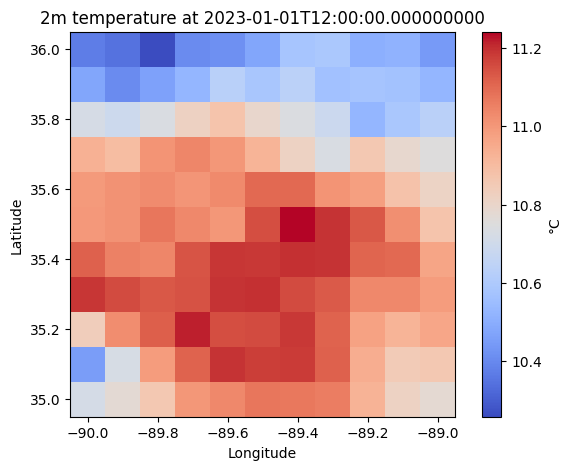

In [ ]:


# choose a time index (0 = first available valid_time)
time_idx = 0
time = weather_array.valid_time.values[time_idx]

# extract 2m temperature (variable name in the dataset is "t2m")
t2m = weather_array["t2m"].isel(valid_time=time_idx)

# convert to Celsius if values look like Kelvin
if t2m.mean().item() > 200:
    t2m_plot = t2m - 273.15
    units = "°C"
else:
    t2m_plot = t2m
    units = weather_array["t2m"].attrs.get("units", "")

lon = weather_array.longitude
lat = weather_array.latitude

plt.figure(figsize=(7, 5))
pcm = plt.pcolormesh(lon, lat, t2m_plot, shading="auto", cmap="coolwarm")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"2m temperature at {str(time)}")
plt.colorbar(pcm, label=units)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()